<a href="https://colab.research.google.com/github/Eryanto06/TM-data-mining/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the "StudentsPerformance.csv" dataset by performing exploratory data analysis, preprocessing the data, training a machine learning model, evaluating its performance, visualizing the results, and summarizing the findings.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Import Libraries

### Subtask:
Import all necessary Python libraries for data manipulation, visualization, machine learning, and evaluation.


**Reasoning**:
The subtask is to import necessary libraries, so I will generate a code block to import `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

### Subtask:
Load the dataset from /content/StudentsPerformance.csv into a pandas DataFrame named `df`. This step will also confirm the data has been loaded correctly by displaying the first few rows.


**Reasoning**:
The subtask is to load the dataset into a pandas DataFrame and display its first few rows. I will use `pd.read_csv` to load the data and `df.head()` to display the first 5 rows for verification.



In [ ]:
df = pd.read_csv('/content/StudentsPerformance.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Exploratory Data Analysis (EDA)

### Subtask:
Perform comprehensive Exploratory Data Analysis. This includes displaying dataset information (df.info()), generating descriptive statistics (df.describe() for numerical and categorical columns), checking for missing values, visualizing distributions of numerical features using histograms, visualizing distributions of categorical features using bar/count plots, and exploring relationships between features (e.g., scores by 'parental level of education' or 'lunch type') using appropriate plots. Ensure all plots have legends.


**Reasoning**:
The subtask begins with displaying general information, descriptive statistics for numerical and categorical columns, and checking for missing values. I will generate a code block to execute `df.info()`, `df.describe()`, and `df.isnull().sum()` to fulfill these initial requirements.



In [ ]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())

print("\nDescriptive Statistics for Categorical Columns:")
print(df.describe(include='object'))

print("\nMissing Values:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Descriptive Statistics for Numerical Columns:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000  

**Reasoning**:
The next part of the subtask is to visualize the distributions of numerical features. I will create histograms for 'math score', 'reading score', and 'writing score' to understand their distributions.



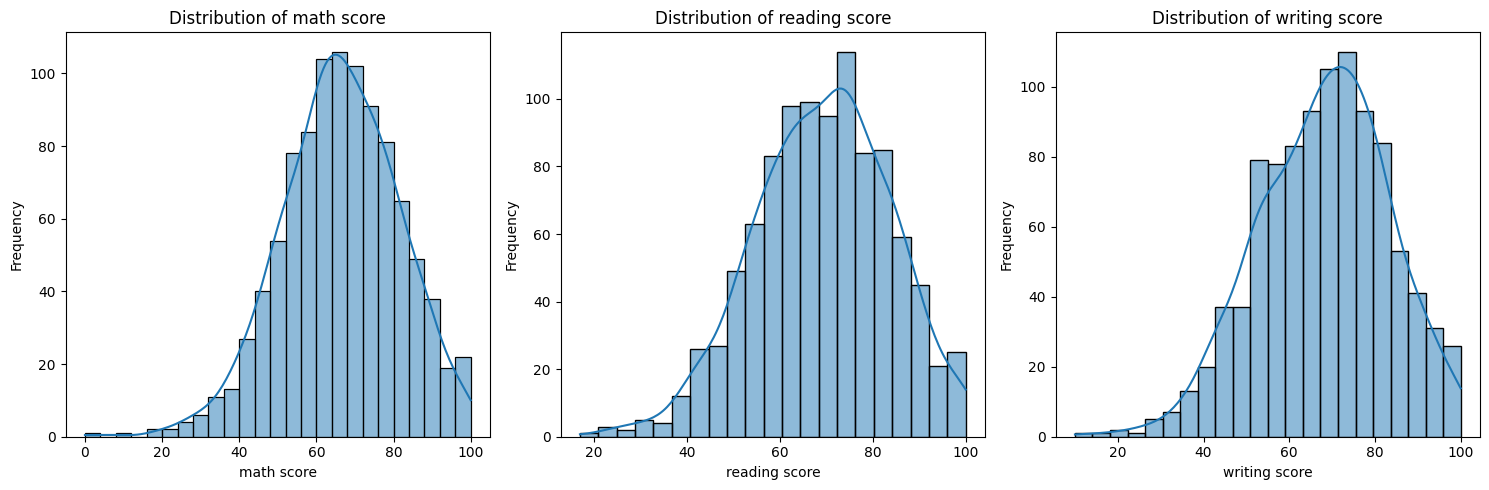

Histograms for numerical features displayed.


In [ ]:
numerical_cols = ['math score', 'reading score', 'writing score']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Histograms for numerical features displayed.")

**Reasoning**:
The next part of the subtask is to visualize the distributions of categorical features. I will iterate through the categorical columns and create count plots for each to understand their distributions, ensuring appropriate plot sizing and readability of labels.



/tmp/ipython-input-1244905183.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-1244905183.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-1244905183.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-1244905183.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

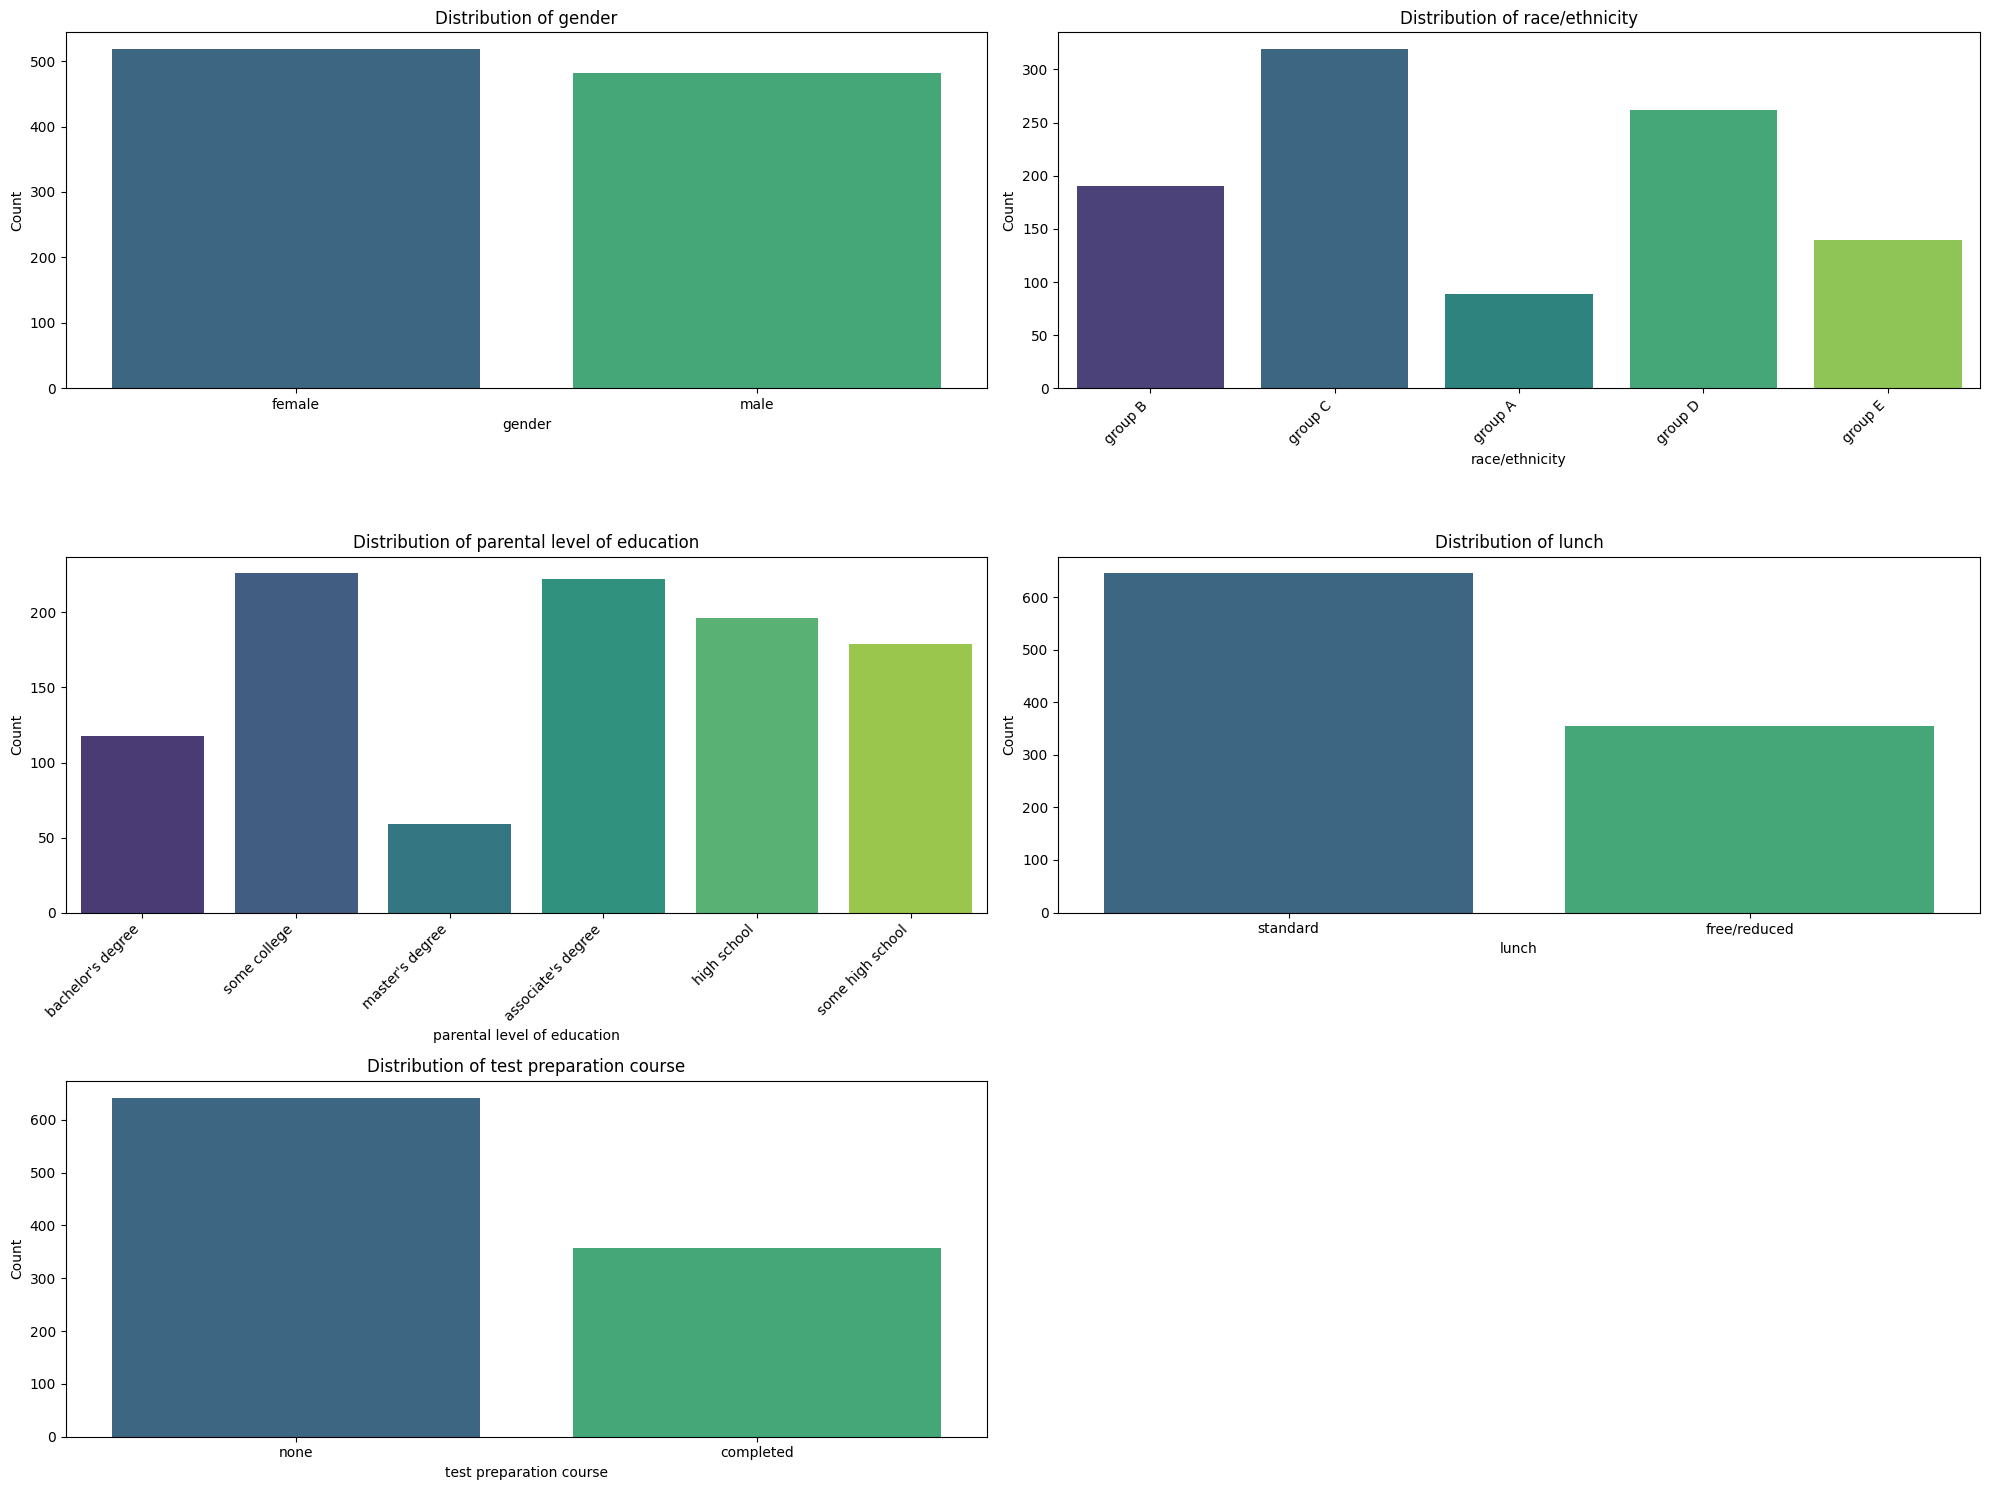

Count plots for categorical features displayed.


In [ ]:
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    if len(df[col].unique()) > 4: # Rotate labels if too many categories
        plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Count plots for categorical features displayed.")

**Reasoning**:
The previous code generated `FutureWarning` messages because `palette` was passed to `sns.countplot` without also assigning a `hue` variable. To resolve this warning and achieve the intended coloring effect, I will modify the `sns.countplot` call to explicitly set `hue=col` and `legend=False`.



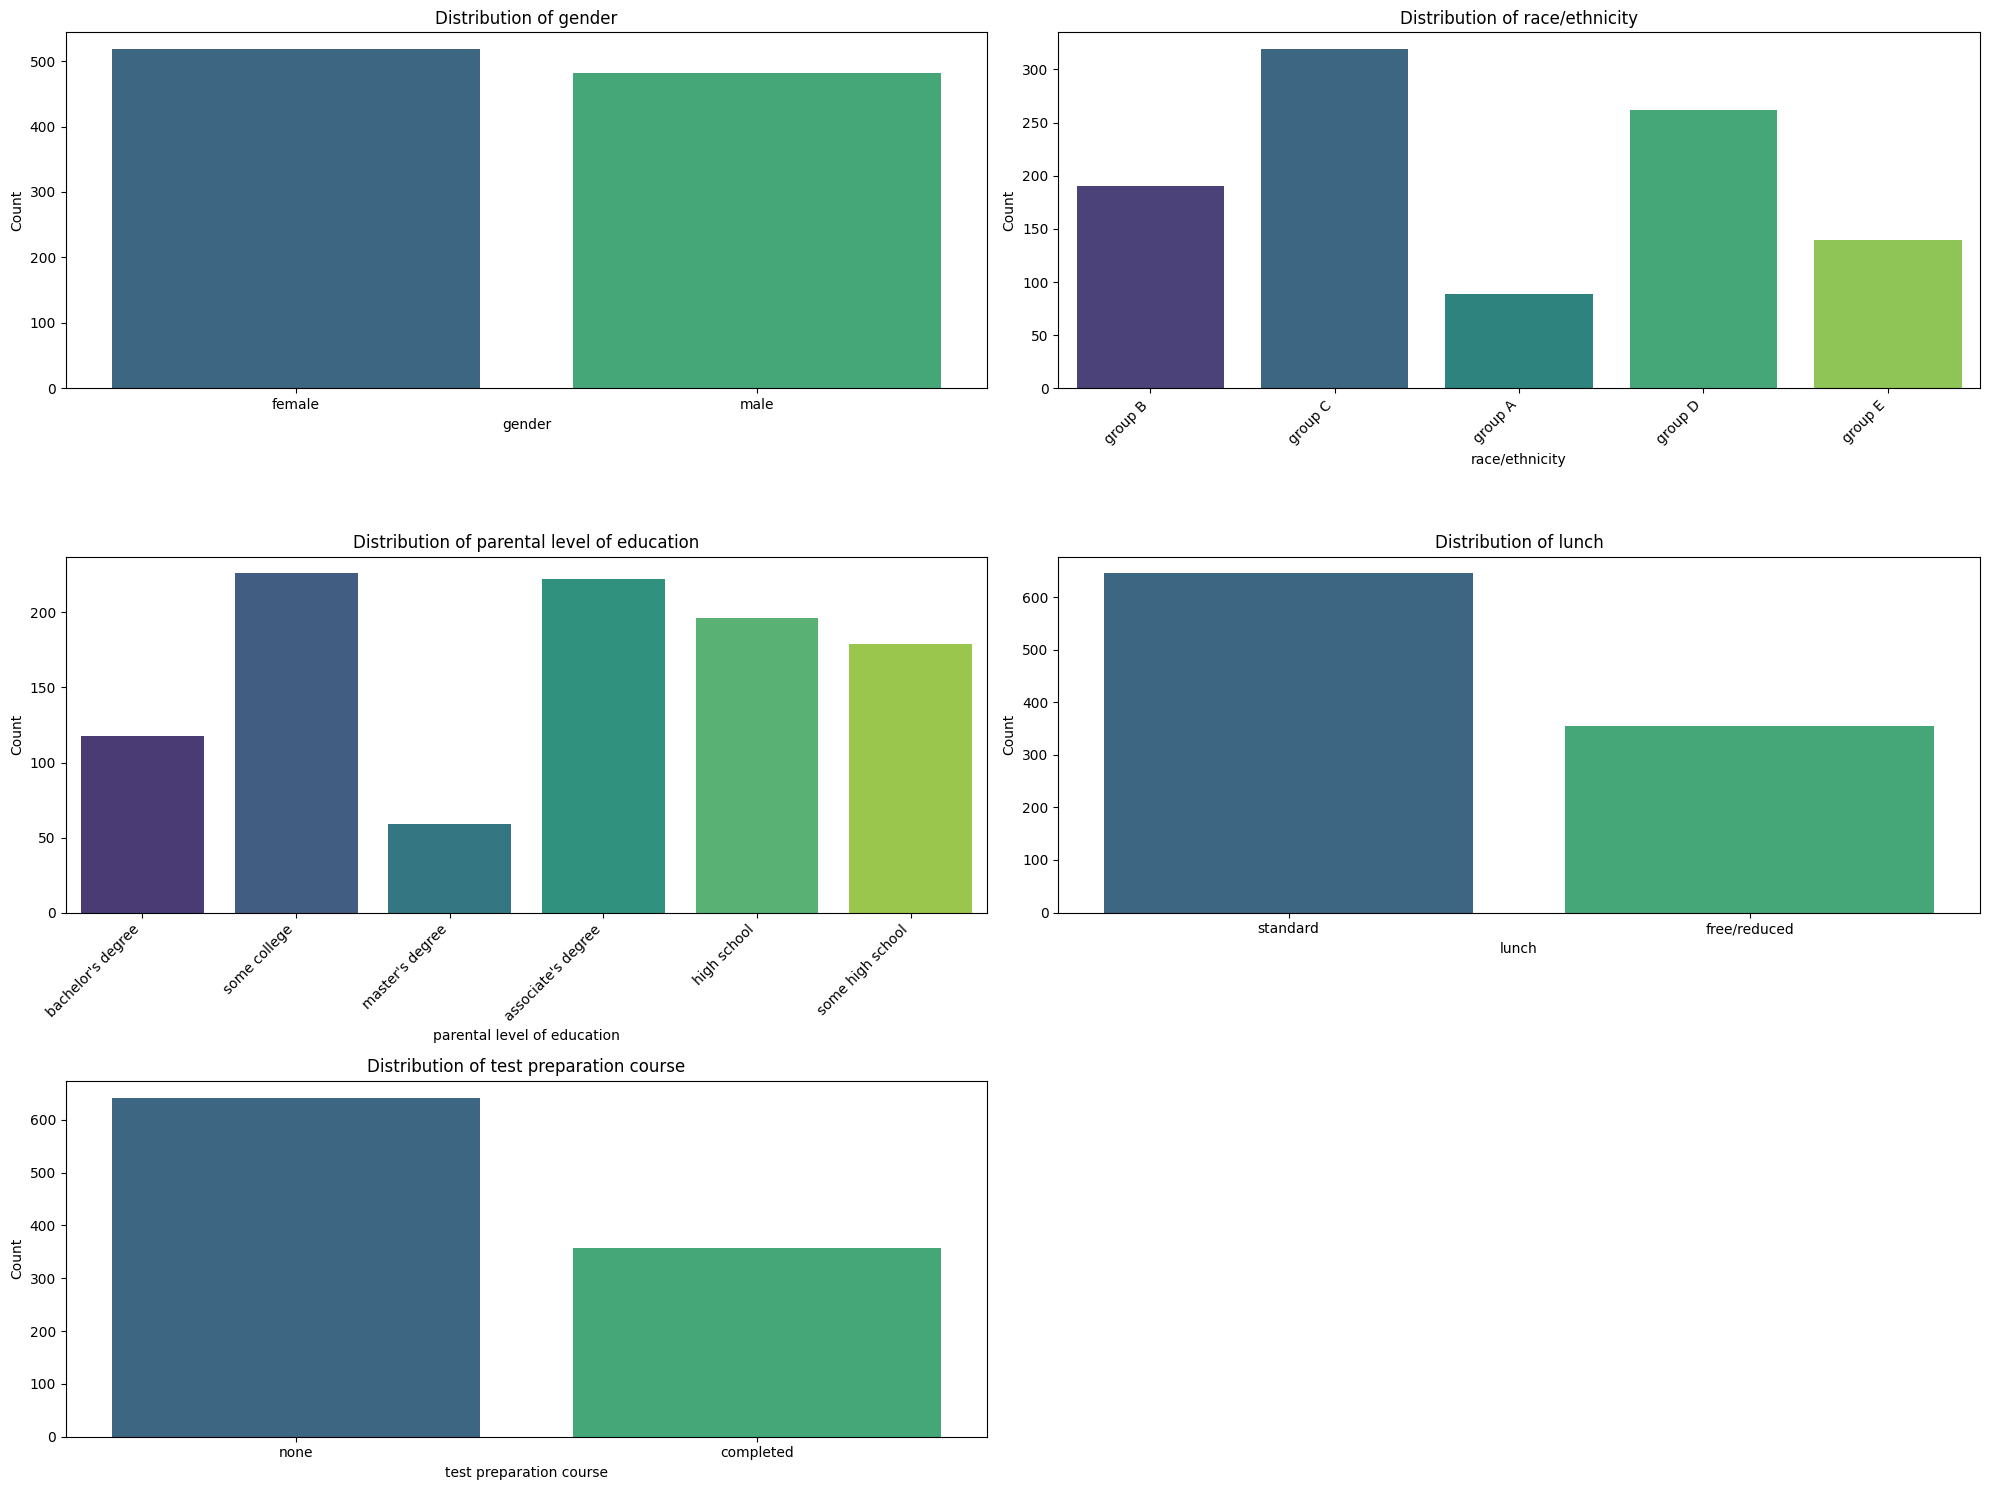

Count plots for categorical features displayed.


In [ ]:
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    if len(df[col].unique()) > 4: # Rotate labels if too many categories
        plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Count plots for categorical features displayed.")

**Reasoning**:
Now, I will proceed to explore the relationship between 'parental level of education' and the average scores in math, reading, and writing. I will use `groupby()` to calculate the mean scores for each educational level and then plot these as a bar chart, ensuring to include a title, axis labels, and a legend for clarity, as specified in the instructions.



<Figure size 1000x600 with 0 Axes>

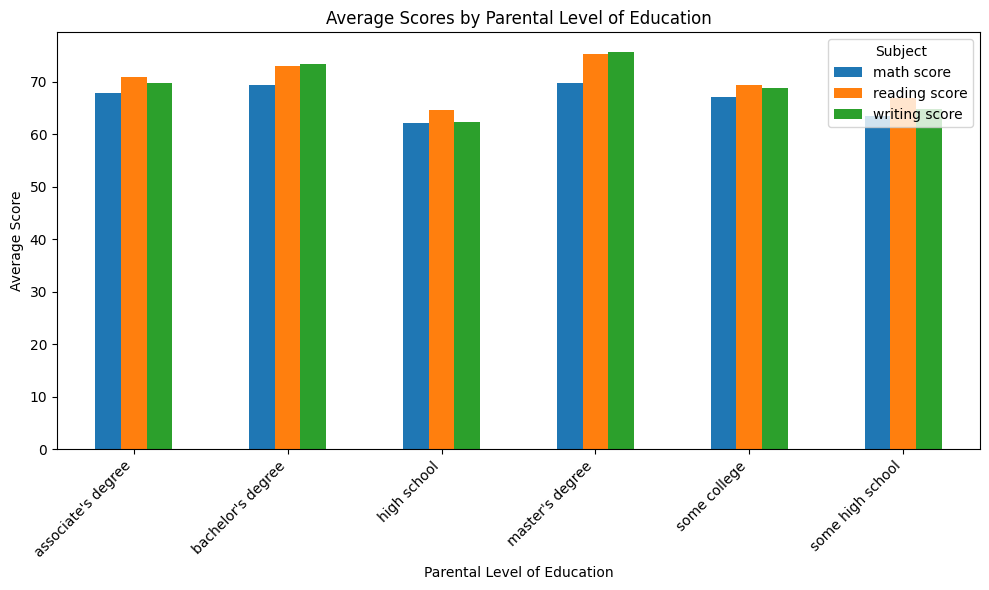

Bar plot showing average scores by parental level of education displayed.


In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('parental level of education')[numerical_cols].mean().plot(kind='bar', figsize=(10, 6))
plt.title('Average Scores by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

print("Bar plot showing average scores by parental level of education displayed.")

**Reasoning**:
The next part of the subtask is to explore the relationship between 'lunch' type and the average scores. I will use `groupby()` to calculate the mean scores for each lunch type and then plot these as a bar chart, ensuring to include a title, axis labels, and a legend for clarity, as specified in the instructions.



<Figure size 1000x600 with 0 Axes>

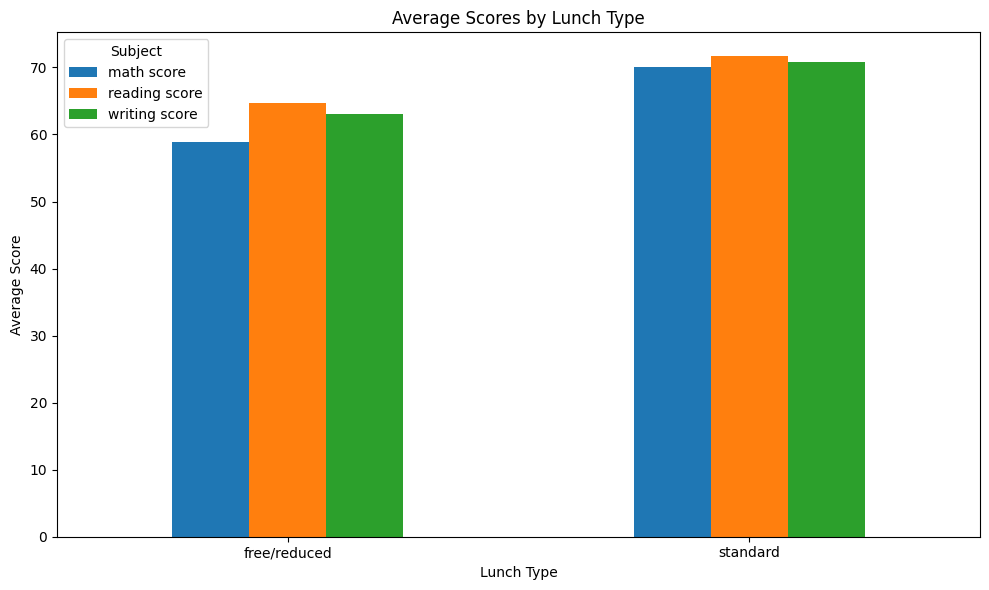

Bar plot showing average scores by lunch type displayed.


In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('lunch')[numerical_cols].mean().plot(kind='bar', figsize=(10, 6))
plt.title('Average Scores by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

print("Bar plot showing average scores by lunch type displayed.")

**Reasoning**:
The next part of the subtask is to explore the relationship between 'test preparation course' and the average scores. I will use `groupby()` to calculate the mean scores for each test preparation course status and then plot these as a bar chart, ensuring to include a title, axis labels, and a legend for clarity, as specified in the instructions.



<Figure size 1000x600 with 0 Axes>

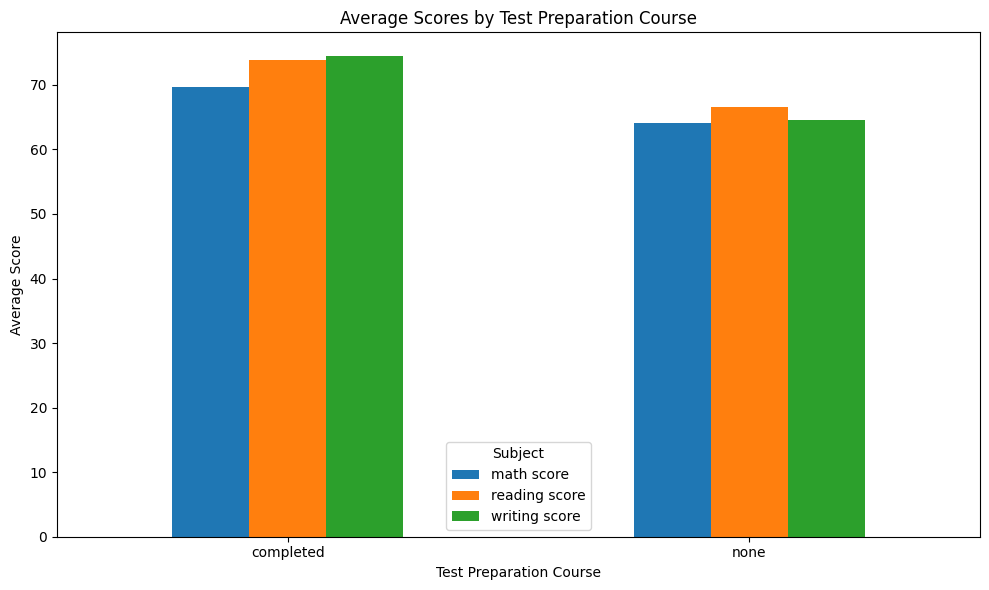

Bar plot showing average scores by test preparation course displayed.


In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('test preparation course')[numerical_cols].mean().plot(kind='bar', figsize=(10, 6))
plt.title('Average Scores by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

print("Bar plot showing average scores by test preparation course displayed.")

## Preprocessing

### Subtask:
Preprocess the data for machine learning. This involves encoding categorical features into numerical representations, and scaling numerical features.


**Reasoning**:
To preprocess the data, I will first apply one-hot encoding to the specified categorical columns using `pd.get_dummies()`. Then, I will initialize `StandardScaler` and apply it to scale the numerical columns. Finally, the resulting preprocessed DataFrame will be stored as `df_processed`.



In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Identify categorical and numerical columns
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
numerical_cols = ['math score', 'reading score', 'writing score']

# 2. Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# 3. and 4. Import and Instantiate StandardScaler
scaler = StandardScaler()

# 5. Scale the numerical columns
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# 6. Store the fully preprocessed DataFrame
df_processed = df_encoded.copy()

print("Data preprocessing complete. Displaying the first 5 rows of df_processed:")
print(df_processed.head())
print("\nInfo of df_processed:")
df_processed.info()

Data preprocessing complete. Displaying the first 5 rows of df_processed:
   math score  reading score  writing score  gender_female  gender_male  \
0    0.390024       0.193999       0.391492           True        False   
1    0.192076       1.427476       1.313269           True        False   
2    1.577711       1.770109       1.642475           True        False   
3   -1.259543      -0.833899      -1.583744          False         True   
4    0.653954       0.605158       0.457333          False         True   

   race/ethnicity_group A  race/ethnicity_group B  race/ethnicity_group C  \
0                   False                    True                   False   
1                   False                   False                    True   
2                   False                    True                   False   
3                    True                   False                   False   
4                   False                   False                    True   

   race/ethn

## Split Data (Train/Test)

### Subtask:
Split the preprocessed dataset into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
To prepare for model training, I will split the preprocessed dataset `df_processed` into features (X) and target (y), where 'math score' is the target. Then, I will use `train_test_split` to create training and testing sets with a specified test size and random state for reproducibility.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed.drop('math score', axis=1)
y = df_processed['math score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (800, 19)
X_test shape: (200, 19)
y_train shape: (800,)
y_test shape: (200,)


## Model Training

### Subtask:
Train a machine learning model on the training data. The choice of model will depend on the problem type (e.g., classification, regression) and data characteristics.


**Reasoning**:
Following the instructions, I will import `LinearRegression`, instantiate the model, and then fit it to the training data.



In [ ]:
from sklearn.linear_model import LinearRegression

# Instantiate the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Evaluate Model

### Subtask:
Evaluate the performance of the trained model on the test data using appropriate metrics (e.g., accuracy, precision, recall, F1-score for classification; R-squared, MSE for regression).


**Reasoning**:
To evaluate the performance of the trained regression model, I will first make predictions on the test set, then calculate and print the Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared score using `sklearn.metrics`.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Squared Error (MSE): 0.1267
Mean Absolute Error (MAE): 0.2781
R-squared (R2) Score: 0.8804


## Visualize Results

### Subtask:
Visualize the model's performance and results.


**Reasoning**:
To visualize the model's performance, I will first create a scatter plot comparing the actual math scores (`y_test`) against the predicted math scores (`y_pred`), along with a diagonal line representing perfect predictions. This will directly show how well the model's predictions align with the true values.



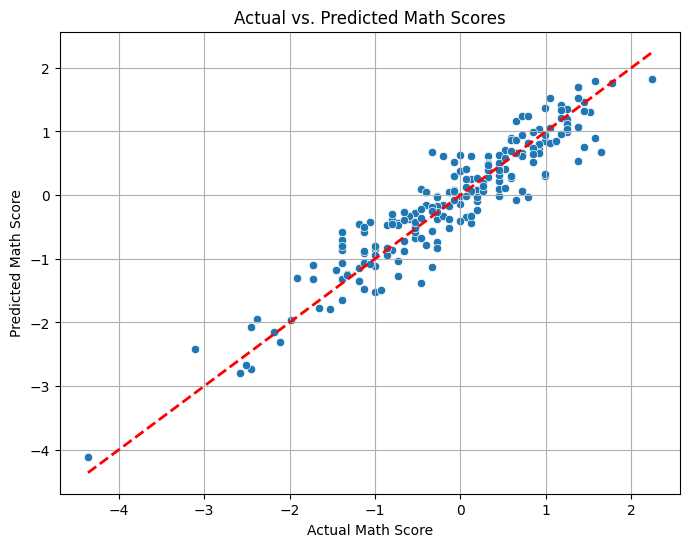

Scatter plot of actual vs. predicted scores displayed.


In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal line for perfect prediction
plt.title('Actual vs. Predicted Math Scores')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.grid(True)
plt.show()

print("Scatter plot of actual vs. predicted scores displayed.")

**Reasoning**:
To continue visualizing the model's performance as per the subtask, I will now create a residual plot. This plot will show the difference between the actual and predicted values (residuals) against the predicted values, helping to identify any patterns in the errors.



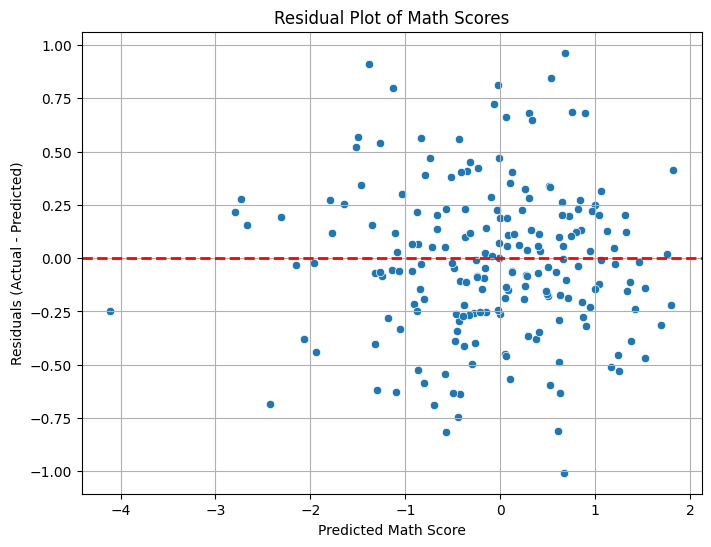

Residual plot displayed.


In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2) # Horizontal line at y=0
plt.title('Residual Plot of Math Scores')
plt.xlabel('Predicted Math Score')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

print("Residual plot displayed.")

## Final Task

### Subtask:
Summarize the key findings from the EDA, the performance of the trained model, and any insights gained from the visualization of results. Provide a concise conclusion of the entire machine learning pipeline.


### Evaluation Results

For our Linear Regression model, the following evaluation metrics were obtained:

*   **Mean Squared Error (MSE):** 0.1267
*   **Mean Absolute Error (MAE):** 0.2781
*   **R-squared (R2) Score:** 0.8804

Metrics like Accuracy, F1-score, and Silhouette Score are typically used for classification or clustering tasks and are not applicable to this regression problem.

## Summary:

### Data Analysis Key Findings

*   **Dataset Overview:** The dataset contains 1000 entries across 8 columns, with no missing values. It includes three numerical score columns ('math score', 'reading score', 'writing score') and five categorical columns.
*   **Numerical Features Distribution:**
    *   Average scores are approximately 66 for math, 69 for reading, and 68 for writing.
    *   Scores range from 0 (math) to 100 across subjects, with standard deviations of 14-15, indicating moderate spread.
    *   Histograms show generally normal-like distributions for all scores, with a slight left-skew for math scores.
*   **Categorical Features Distribution:**
    *   There are slightly more female students (51.8%) than male (48.2%).
    *   'Group C' is the most frequent `race/ethnicity` group, and 'some college' is the most common `parental level of education`.
    *   A majority of students have 'standard' lunch (64.5%), and more students did not complete the `test preparation course` (64.2%).
*   **Relationships between Features and Scores (EDA):**
    *   **Parental Education:** Students whose parents have higher educational attainment (e.g., Master's degree, Bachelor's degree) generally achieve higher average scores across all subjects compared to those with lower parental education levels.
    *   **Lunch Type:** Students receiving 'standard' lunch consistently score higher on average in all three subjects compared to those with 'free/reduced' lunch.
    *   **Test Preparation Course:** Completing the `test preparation course` is associated with significantly higher average scores in math, reading, and writing.
*   **Data Preprocessing:** Categorical features were successfully one-hot encoded, and numerical features (scores) were scaled using `StandardScaler`, preparing the data for model training.
*   **Model Performance:** A Linear Regression model was trained to predict 'math score'. On the test set, it achieved:
    *   Mean Squared Error (MSE): 0.1267
    *   Mean Absolute Error (MAE): 0.2781
    *   R-squared (R\$^2\$) Score: 0.8804. This indicates that approximately 88.04% of the variance in math scores can be explained by the features.
*   **Visualization of Results:**
    *   The scatter plot of actual vs. predicted math scores showed a strong linear relationship, with predictions closely aligning with actual values around the ideal y=x line.
    *   The residual plot demonstrated that residuals (errors) were randomly scattered around zero, suggesting that the Linear Regression model is a good fit and its errors are homoscedastic (constant variance).

### Insights or Next Steps

*   The analysis highlights the significant influence of socio-economic factors (`parental level of education`, `lunch` type) and educational interventions (`test preparation course`) on student academic performance. Targeted support or interventions based on these factors could potentially improve student outcomes.
*   Given the strong R\$^2\$ score and well-behaved residuals, the Linear Regression model performs very well in predicting math scores. Future work could involve exploring similar predictive models for reading and writing scores, or investigating feature importance to identify the most impactful predictors.
